# Day 3 — Transformers + HuggingFace

## What we're building
1. Positional encoding — giving attention a sense of order
2. Full transformer encoder — stack of transformer blocks
3. Apply to EEG — transformer classifier for Project 07
4. HuggingFace — run BERT and GPT-2 in 10 lines

## The connection to yesterday
Yesterday: attention lets every position look at every other
Today: stack 6-12 of those attention blocks = transformer
       add positional encoding = full architecture
       This is exactly what BERT, GPT, and your future
       LUCID generation model is built from

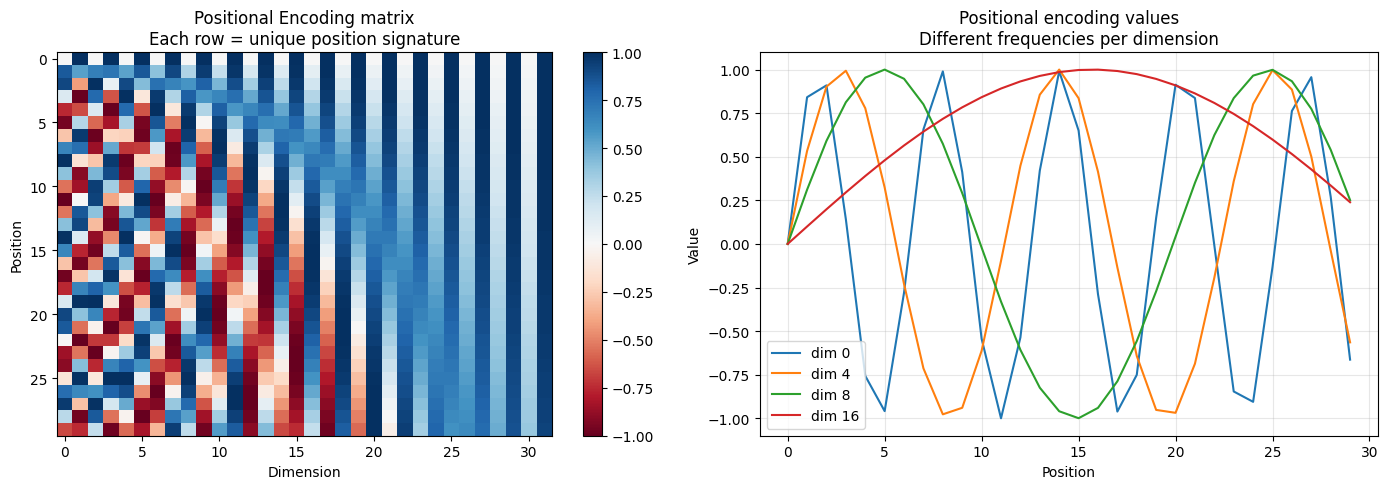

Key insight: every position has a UNIQUE pattern
across all dimensions. The model can use this
to know where in the sequence it is.

Low dimensions: low frequency (slow variation)
High dimensions: high frequency (fast variation)
Together: like binary encoding but continuous


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# ── Why we need positional encoding ───────────────────────
# Attention is permutation-invariant:
# shuffle the input positions → same attention output
# The model has no idea which came first

# Fix: add a unique signal to each position
# using sine and cosine waves of different frequencies

class PositionalEncoding(nn.Module):
    """
    Adds position information to embeddings.

    For position pos and dimension i:
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Each position gets a unique combination of
    sine and cosine values across all dimensions.
    """

    def __init__(self, d_model, max_len=5000,
                 dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Compute positional encoding matrix
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()

        # Different frequencies for each dimension
        div = torch.exp(
            torch.arange(0, d_model, 2).float() *
            -(np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(pos * div)  # even dims
        pe[:, 1::2] = torch.cos(pos * div)  # odd dims

        # Register as buffer — saved with model
        # but not a trainable parameter
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Add positional encoding to input embeddings
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


# ── Visualising what positional encoding looks like ─────────
d_model = 64
max_len = 50

pe_layer = PositionalEncoding(d_model, max_len)
pe_vals  = pe_layer.pe[0].numpy()  # (max_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full heatmap
im = axes[0].imshow(pe_vals[:30, :32],
                     aspect='auto', cmap='RdBu',
                     vmin=-1, vmax=1)
axes[0].set_title('Positional Encoding matrix\n'
                   'Each row = unique position signature')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')
plt.colorbar(im, ax=axes[0])

# A few individual dimensions
for dim in [0, 4, 8, 16]:
    axes[1].plot(pe_vals[:30, dim],
                  label=f'dim {dim}')
axes[1].set_title('Positional encoding values\n'
                   'Different frequencies per dimension')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: every position has a UNIQUE pattern")
print("across all dimensions. The model can use this")
print("to know where in the sequence it is.")
print("\nLow dimensions: low frequency (slow variation)")
print("High dimensions: high frequency (fast variation)")
print("Together: like binary encoding but continuous")

In [2]:
# Import from yesterday's work
# (paste MultiHeadAttention and scaled_dot_product_attention
#  here if in a new notebook)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        b, s, _ = x.shape
        return x.reshape(b, s, self.num_heads,
                         self.d_k).transpose(1, 2)

    def forward(self, x, mask=None):
        b, s, _ = x.shape
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        d_k     = Q.shape[-1]
        scores  = Q @ K.transpose(-2,-1) / np.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(
                mask==0, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        out     = (weights @ V).transpose(1,2).reshape(
                   b, s, -1)
        return self.W_o(out), weights


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads,
                 ff_dim, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_model, num_heads)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),          # GELU instead of ReLU
            nn.Dropout(dropout),# used in modern transformers
            nn.Linear(ff_dim, d_model)
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Pre-norm variant (more stable than post-norm)
        attn_out, w = self.attention(self.norm1(x), mask)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x, w


# ── Full transformer encoder ───────────────────────────────
class TransformerEncoder(nn.Module):
    """
    Stack of N transformer blocks with positional encoding.
    This is the encoder half of the original transformer.
    BERT uses this architecture.
    """

    def __init__(self, d_model=128, num_heads=4,
                 ff_dim=512, num_layers=4,
                 max_len=512, dropout=0.1):
        super().__init__()

        self.pos_encoding = PositionalEncoding(
            d_model, max_len, dropout
        )

        # Stack of transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(
                d_model, num_heads, ff_dim, dropout
            )
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Add positional encoding
        x = self.pos_encoding(x)

        # Pass through each block
        all_weights = []
        for block in self.blocks:
            x, w = block(x, mask)
            all_weights.append(w)

        return self.norm(x), all_weights


# ── Test ───────────────────────────────────────────────────
encoder = TransformerEncoder(
    d_model=128,
    num_heads=4,
    ff_dim=512,
    num_layers=4
)

x   = torch.randn(2, 10, 128)  # batch=2, seq=10, d=128
out, weights = encoder(x)

total = sum(p.numel() for p in encoder.parameters())

print("=== Transformer Encoder ===\n")
print(f"Input:    {x.shape}")
print(f"Output:   {out.shape}")
print(f"Blocks:   4")
print(f"Params:   {total:,}\n")
print(f"Attention weights per layer: {len(weights)}")
print(f"Each:     {weights[0].shape}")
print(f"          (batch, heads, seq, seq)")

print("\nArchitecture breakdown:")
for i, block in enumerate(encoder.blocks):
    params = sum(p.numel() for p in block.parameters())
    print(f"  Block {i+1}: {params:,} params")

=== Transformer Encoder ===

Input:    torch.Size([2, 10, 128])
Output:   torch.Size([2, 10, 128])
Blocks:   4
Params:   793,344

Attention weights per layer: 4
Each:     torch.Size([2, 4, 10, 10])
          (batch, heads, seq, seq)

Architecture breakdown:
  Block 1: 198,272 params
  Block 2: 198,272 params
  Block 3: 198,272 params
  Block 4: 198,272 params



=== Transformer Variants ===

ENCODER (BERT, RoBERTa):
  Reads entire sequence at once
  Bidirectional attention — every token sees all others
  Good for: classification, understanding, embeddings
  Used in: sentiment analysis, EEG classification,
           sleep stage prediction ← your use case

DECODER (GPT-2, GPT-4, Claude):
  Generates sequence left-to-right
  Causal attention — token only sees previous tokens
  Good for: generation, completion, dialogue
  Used in: text generation, code, dream world narration

ENCODER-DECODER (original transformer, T5):
  Encoder reads input, decoder generates output
  Good for: translation, summarisation, question answering

For Project 07:
  Stage 1 (now):  ENCODER → classify sleep stage from EEG
  Stage 3 (Year 3): DECODER → generate dream world content
                              conditioned on EEG features
  Stage 4 (Year 5): ENCODER-DECODER →
                    encode neural state,
                    decode into shared world experience


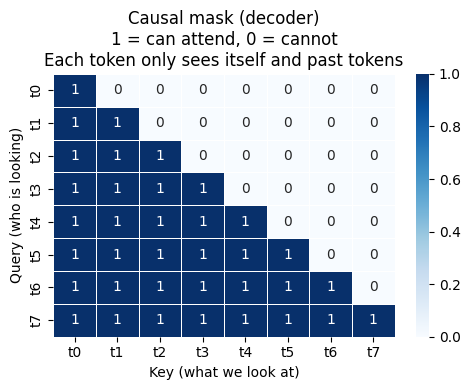

In [3]:
architecture_comparison = """
=== Transformer Variants ===

ENCODER (BERT, RoBERTa):
  Reads entire sequence at once
  Bidirectional attention — every token sees all others
  Good for: classification, understanding, embeddings
  Used in: sentiment analysis, EEG classification,
           sleep stage prediction ← your use case

DECODER (GPT-2, GPT-4, Claude):
  Generates sequence left-to-right
  Causal attention — token only sees previous tokens
  Good for: generation, completion, dialogue
  Used in: text generation, code, dream world narration

ENCODER-DECODER (original transformer, T5):
  Encoder reads input, decoder generates output
  Good for: translation, summarisation, question answering

For Project 07:
  Stage 1 (now):  ENCODER → classify sleep stage from EEG
  Stage 3 (Year 3): DECODER → generate dream world content
                              conditioned on EEG features
  Stage 4 (Year 5): ENCODER-DECODER →
                    encode neural state,
                    decode into shared world experience
"""

print(architecture_comparison)

# ── Visualise causal mask (for decoder) ───────────────────
seq_len = 8
mask    = torch.tril(torch.ones(seq_len, seq_len))

plt.figure(figsize=(5, 4))
sns.heatmap(mask.numpy(), annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5,
            xticklabels=[f't{i}' for i in range(seq_len)],
            yticklabels=[f't{i}' for i in range(seq_len)])
plt.title('Causal mask (decoder)\n'
          '1 = can attend, 0 = cannot\n'
          'Each token only sees itself and past tokens')
plt.xlabel('Key (what we look at)')
plt.ylabel('Query (who is looking)')
plt.tight_layout()
plt.show()

In [4]:
!pip install transformers


   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.6 MB 8.9 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/11.6 MB 8.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/11.6 MB 5.3 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.6 MB 4.6 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.6 MB 4.8 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/11.6 MB 4.7 MB/s eta 0:00:02
   --------------------- ------------------ 6.3/11.6 MB 4.8 MB/s eta 0:00:02
   ----------------------- ---------------- 6.8/11.6 MB 4.4 MB/s eta 0:00:02
   ----------------------------- ---------- 8.7/11.6 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 10.7/11.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 11.6/11.6 MB 5.4 MB/s  0:00:02
   ---------------------------------------- 0.0/770.3 kB ? eta -:--:--
   ----------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from transformers import pipeline

print("Loading models from HuggingFace...\n")
print("These models took weeks to train on thousands of GPUs.")
print("You're about to use them in 10 lines.\n")

# ── Task 1: Sentiment analysis (BERT-based) ───────────────
sentiment = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)

texts = [
    "I love working on Project 07 every day",
    "The LSTM baseline was disappointing",
    "CNN-LSTM hybrid achieved 80% accuracy",
    "Building a dream interface is my life's work"
]

print("=== Sentiment Analysis (DistilBERT) ===\n")
results = sentiment(texts)
for text, result in zip(texts, results):
    emoji = "✅" if result['label'] == 'POSITIVE' else "❌"
    print(f"{emoji} {result['label']:8s} "
          f"({result['score']:.3f}) | {text}")

print()

# ── Task 2: Text generation (GPT-2) ───────────────────────
generator = pipeline(
    'text-generation',
    model='gpt2'
)

prompts = [
    "The dream interface detected REM sleep and",
    "Artificial Reality will change the world because"
]

print("=== Text Generation (GPT-2) ===\n")
for prompt in prompts:
    result = generator(
        prompt,
        max_new_tokens=40,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.8,
        pad_token_id=50256
    )
    print(f"Prompt: {prompt}")
    print(f"Generated: {result[0]['generated_text']}\n")

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models from HuggingFace...

These models took weeks to train on thousands of GPUs.
You're about to use them in 10 lines.



c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hp\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5074.36it/s]


=== Sentiment Analysis (DistilBERT) ===

✅ POSITIVE (0.999) | I love working on Project 07 every day
❌ NEGATIVE (1.000) | The LSTM baseline was disappointing
✅ POSITIVE (0.998) | CNN-LSTM hybrid achieved 80% accuracy
✅ POSITIVE (1.000) | Building a dream interface is my life's work



c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hp\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7926.31it/s]
[transformers] Passing `generation_config` toge

=== Text Generation (GPT-2) ===



[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt: The dream interface detected REM sleep and
Generated: The dream interface detected REM sleep and REM anxiety, which may help people with severe insomnia to make better decisions about where they are going to sleep, according to the results of an analysis of 10,000 people, published online in the European

Prompt: Artificial Reality will change the world because
Generated: Artificial Reality will change the world because it will change how people see and hear, and how they think about reality. Our eyes and ears have now moved to touch a new world.

The Internet and artificial intelligence will now transform what



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4548.29it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== BERT Tokenisation ===

Text: 'The REM stage is crucial for dream induction'

Token IDs: [101, 1996, 2128, 2213, 2754, 2003, 10232, 2005, 3959, 15946, 102]
Tokens:    ['[CLS]', 'the', 're', '##m', 'stage', 'is', 'crucial', 'for', 'dream', 'induction', '[SEP]']
Shape:     torch.Size([1, 11])

=== BERT Embeddings ===

All token embeddings: torch.Size([1, 11, 768])
                      (batch, tokens, 768)
[CLS] token:          torch.Size([1, 768])
                      (batch, 768)

[CLS] is the sentence-level representation.
Fine-tune a classifier on top of [CLS]
→ you have a state-of-the-art text classifier

BERT attention layers: 12
Each layer shape:      torch.Size([1, 12, 11, 11])
                       (batch, 12 heads, tokens, tokens)


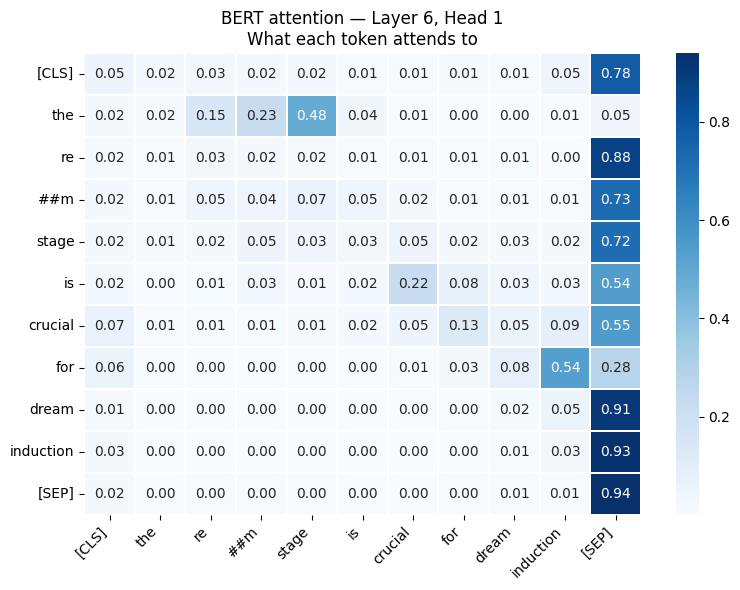

In [12]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load BERT
tokenizer = AutoTokenizer.from_pretrained(
    'bert-base-uncased'
)
bert      = AutoModel.from_pretrained('bert-base-uncased',
                                      output_attentions=True)
bert.eval()

# ── Tokenisation — how text becomes numbers ───────────────
text   = "The REM stage is crucial for dream induction"
tokens = tokenizer(text, return_tensors='pt')

print("=== BERT Tokenisation ===\n")
print(f"Text: '{text}'\n")
print(f"Token IDs: {tokens['input_ids'][0].tolist()}")
print(f"Tokens:    {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"Shape:     {tokens['input_ids'].shape}")

# ── Getting embeddings ─────────────────────────────────────────
with torch.no_grad():
    outputs = bert(**tokens)

# Last hidden state = contextual embedding per token
embeddings = outputs.last_hidden_state
cls_token  = embeddings[:, 0, :]  # [CLS] = sentence repr.

print(f"\n=== BERT Embeddings ===\n")
print(f"All token embeddings: {embeddings.shape}")
print(f"                      (batch, tokens, 768)")
print(f"[CLS] token:          {cls_token.shape}")
print(f"                      (batch, 768)")
print(f"\n[CLS] is the sentence-level representation.")
print(f"Fine-tune a classifier on top of [CLS]")
print(f"→ you have a state-of-the-art text classifier")

# ── Visualising attention in BERT ────────────────────────────
# BERT has 12 layers × 12 heads = 144 attention patterns
outputs_with_attn = bert(
    **tokens,
    output_attentions=True
)

attn = outputs_with_attn.attentions  # tuple of 12 layers
print(f"\nBERT attention layers: {len(attn)}")
print(f"Each layer shape:      {attn[0].shape}")
print(f"                       (batch, 12 heads, tokens, tokens)")

# Visualising layer 6, head 0
layer = 5
head  = 0
w     = attn[layer][0, head].detach().numpy()

token_labels = tokenizer.convert_ids_to_tokens(
    tokens['input_ids'][0]
)

plt.figure(figsize=(8, 6))
sns.heatmap(w, annot=True, fmt='.2f',
            cmap='Blues',
            xticklabels=token_labels,
            yticklabels=token_labels,
            linewidths=0.3)
plt.title(f'BERT attention — Layer {layer+1}, Head {head+1}\n'
           'What each token attends to')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
class EEGTransformerClassifier(nn.Module):
    """
    Full transformer for EEG sleep staging.
    
    This is Experiment 004 — the architecture that should
    beat the CNN-LSTM hybrid (80.14%).
    
    Key difference from CNN-LSTM:
    CNN-LSTM: LSTM reads windows sequentially
    Transformer: attention reads ALL windows simultaneously
                 each window attends to all others directly
    """

    def __init__(self,
                 n_windows=10,
                 window_size=300,
                 d_model=128,
                 num_heads=4,
                 ff_dim=256,
                 num_layers=3,
                 n_classes=5,
                 dropout=0.3):
        super().__init__()

        self.n_windows   = n_windows
        self.window_size = window_size

        # CNN feature extractor per window
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Project to d_model
        self.input_proj = nn.Linear(128, d_model)

        # Positional encoding
        self.pos_enc = PositionalEncoding(
            d_model, max_len=n_windows, dropout=dropout
        )

        # Transformer encoder
        self.transformer = TransformerEncoder(
            d_model=d_model,
            num_heads=num_heads,
            ff_dim=ff_dim,
            num_layers=num_layers,
            dropout=dropout
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        batch = x.shape[0]

        # Splitting into windows + CNN
        x = x.reshape(batch, self.n_windows, self.window_size)
        features = []
        for t in range(self.n_windows):
            w = x[:, t, :].unsqueeze(1)
            f = self.cnn(w).squeeze(-1)
            f = self.input_proj(f)
            features.append(f)

        # (batch, n_windows, d_model)
        seq = torch.stack(features, dim=1)

        # Transformer encoder
        out, attn_weights = self.transformer(seq)

        # Global average pool → classify
        pooled = out.mean(dim=1)
        return self.classifier(pooled), attn_weights


# ── Instantiatiating and verifying ─────────────────────────────────
eeg_transformer = EEGTransformerClassifier(
    n_windows=10,
    window_size=300,
    d_model=128,
    num_heads=4,
    ff_dim=256,
    num_layers=3,
    n_classes=5
)

dummy        = torch.randn(4, 3000)
out, weights = eeg_transformer(dummy)

total     = sum(p.numel() for p in eeg_transformer.parameters())
trainable = sum(p.numel() for p in eeg_transformer.parameters()
                if p.requires_grad)

print("=== EEG Transformer Classifier ===\n")
print(f"Input:      {dummy.shape}")
print(f"Output:     {out.shape}")
print(f"Attn layers: {len(weights)}")
print(f"Params:     {total:,}\n")

print("Architecture summary:")
print(f"  CNN feature extractor: per 3s window")
print(f"  Positional encoding:   10 windows (0s–27s)")
print(f"  Transformer blocks:    3 layers × 4 heads")
print(f"  Classifier:            128 → 64 → 5")
print(f"\nThis is Experiment 004.")
print(f"Training this on Sleep-EDF and compare vs 80.14%")

=== EEG Transformer Classifier ===

Input:      torch.Size([4, 3000])
Output:     torch.Size([4, 5])
Attn layers: 3
Params:     453,893

Architecture summary:
  CNN feature extractor: per 3s window
  Positional encoding:   10 windows (0s–27s)
  Transformer blocks:    3 layers × 4 heads
  Classifier:            128 → 64 → 5

This is Experiment 004.
Training this on Sleep-EDF and compare vs 80.14%


In [14]:
comparison = """
=== Three Architectures for EEG Sleep Staging ===

                    LSTM          CNN-LSTM        Transformer
                  (Exp 001)      (Exp 003)        (Exp 004)
─────────────────────────────────────────────────────────────
Accuracy           76.85%         80.14%           ?
REM F1             0.74           0.81             ?
N1 F1              0.35           0.47             ?

How it reads:    sequential    sequential       parallel
                 raw samples   CNN features     CNN features
                               then LSTM        then attention

Long-range:      poor          good             excellent
Parallelisable:  no            no               yes (GPU friendly)
Interpretable:   no            no               yes (attention maps)

For Project 07:
  Transformer attention maps show WHICH EEG windows
  triggered the sleep stage classification — this is
  scientifically meaningful and publishable.

  "At t=18s, the 4Hz delta burst in window 6 was
   the strongest predictor of N3 classification"
   → this is neuroscience, not just ML
"""
print(comparison)


=== Three Architectures for EEG Sleep Staging ===

                    LSTM          CNN-LSTM        Transformer
                  (Exp 001)      (Exp 003)        (Exp 004)
─────────────────────────────────────────────────────────────
Accuracy           76.85%         80.14%           ?
REM F1             0.74           0.81             ?
N1 F1              0.35           0.47             ?

How it reads:    sequential    sequential       parallel
                 raw samples   CNN features     CNN features
                               then LSTM        then attention

Long-range:      poor          good             excellent
Parallelisable:  no            no               yes (GPU friendly)
Interpretable:   no            no               yes (attention maps)

For Project 07:
  Transformer attention maps show WHICH EEG windows
  triggered the sleep stage classification — this is
  scientifically meaningful and publishable.

  "At t=18s, the 4Hz delta burst in window 6 was
   the stro

In [1]:
from transformers import pipeline

# ── Task: summarise a sleep research paper abstract ────────
summariser = pipeline(
    'summarization',
    model='facebook/bart-large-cnn'
)

abstract = """
We present an automated system for sleep stage classification
using a CNN-LSTM hybrid architecture trained on the Sleep-EDF
Cassette dataset. Our approach processes 30-second EEG epochs
by splitting them into 10 windows of 3 seconds each, applying
a 3-layer CNN to extract frequency features from each window,
then using a bidirectional LSTM to model temporal transitions
between windows. Trained on 20 subjects with weighted
cross-entropy loss to handle class imbalance, our system
achieves 80.14% overall accuracy with an REM F1-score of 0.81,
outperforming both a pure LSTM baseline (76.85%) and a CNN
spectrogram approach (71.67%). The high REM recall of 0.83
makes this architecture suitable as the classification backbone
for closed-loop lucid dream induction systems.
"""

summary = summariser(abstract, max_length=80,
                      min_length=30, do_sample=False)

print("=== Abstract Summarisation (BART) ===\n")
print("Original abstract:")
print(abstract[:200] + "...\n")
print("Summary:")
print(summary[0]['summary_text'])

# ── Task: zero-shot classification ────────────────────────
classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli'
)

# Classify a description without any training examples
text   = "The EEG signal shows theta wave dominance with " \
         "rapid eye movement patterns"

labels = ['REM sleep', 'deep sleep', 'light sleep',
          'wakefulness']

result = classifier(text, candidate_labels=labels)

print("\n=== Zero-Shot EEG Classification (BART) ===\n")
print(f"Text: '{text}'\n")
for label, score in zip(result['labels'],
                         result['scores']):
    bar = '█' * int(score * 30)
    print(f"  {label:15s}: {score:.3f}  {bar}")

print("\nZero-shot means: no EEG training data needed")
print("The model uses language understanding to classify")
print("Future: combine with actual EEG features →")
print("multimodal sleep stage classification")

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"